In [1]:
from doubleml.datasets import fetch_401K

df = fetch_401K(return_type="DataFrame")

df.head()

,nifa,net_tfa,tw,age,inc,fsize,educ,db,marr,twoearn,e401,p401,pira,hown
0,0.0,0.0,4500.0,47,6765.0,2,8,0,0,0,0,0,0,1
1,6215.0,1015.0,22390.0,36,28452.0,1,16,0,0,0,0,0,0,1
2,0.0,-2000.0,-2000.0,37,3300.0,6,12,1,0,0,0,0,0,0
3,15000.0,15000.0,155000.0,58,52590.0,2,16,0,1,1,0,0,0,1
4,0.0,0.0,58000.0,32,21804.0,1,11,0,0,0,0,0,0,1


In [2]:
# Define the outcome, treatment, and confounding variables for the causal analysis

outcome = "net_tfa"

treatment = "e401"

confounders = [
    "age",
    "inc",
    "fsize",
    "educ",
    "db",
    "marr",
    "twoearn",
    "pira",
    "hown"
]

print("Outcome:", outcome)
print("Treatment:", treatment)
print("Confounders:", confounders)

Outcome: net_tfa
Treatment: e401
Confounders: ['age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'pira', 'hown']


In [4]:
# Create a DoubleML data object that defines Y, D, and X for the causal model

from doubleml import DoubleMLData

dml_data = DoubleMLData(
    df,
    y_col=outcome,
    d_cols=treatment,
    x_cols=confounders
)

print(dml_data)

================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: net_tfa
Treatment variable(s): ['e401']
Covariates: ['age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'pira', 'hown']
Instrument variable(s): None
No. Observations: 9915
------------------ DataFrame info    ------------------
<class 'pandas.DataFrame'>
RangeIndex: 9915 entries, 0 to 9914
Columns: 14 entries, nifa to hown
dtypes: float32(4), int8(10)
memory usage: 251.9 KB



In [5]:
# Create the machine-learning models used inside DoubleML

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Model 1: predicts the outcome (net financial assets)
ml_l = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

# Model 2: predicts treatment probability (401(k) eligibility)
ml_m = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

print("Machine-learning models created successfully.")

Machine-learning models created successfully.


In [6]:
# Create and fit the Double Machine Learning causal model

from doubleml import DoubleMLIRM

dml_model = DoubleMLIRM(
    dml_data,
    ml_g=ml_l,
    ml_m=ml_m,
    n_folds=5
)

dml_model.fit()

print(dml_model.summary)

            coef     std err         t         P>|t|        2.5 %  \
e401  8039.10941  1125.68563  7.141523  9.230267e-13  5832.806119   

            97.5 %  
e401  10245.412702  


In [7]:
# Extract and report the estimated causal effect

effect = dml_model.coef[0]
std_error = dml_model.se[0]

print(f"Estimated causal effect: ${effect:,.2f}")
print(f"Standard error: ${std_error:,.2f}")

Estimated causal effect: $8,039.11
Standard error: $1,125.69


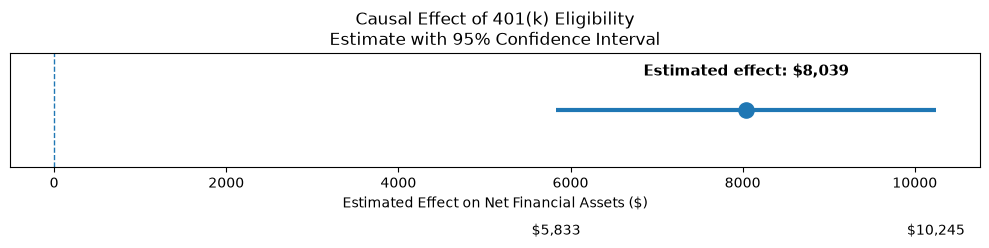

In [9]:
# Visualise the causal effect and 95% confidence interval

import matplotlib.pyplot as plt

effect = dml_model.coef[0]
ci = dml_model.confint()

lower_ci = ci.iloc[0, 0]
upper_ci = ci.iloc[0, 1]

plt.figure(figsize=(10, 3.5))

# Plot confidence interval
plt.hlines(
    y=0,
    xmin=lower_ci,
    xmax=upper_ci,
    linewidth=3
)

# Plot estimated effect
plt.scatter(
    effect,
    0,
    s=120,
    zorder=3
)

# Add estimate label
plt.annotate(
    f"Estimated effect: ${effect:,.0f}",
    xy=(effect, 0),
    xytext=(0, 25),
    textcoords="offset points",
    ha="center",
    fontsize=11,
    fontweight="bold"
)

# Add confidence interval labels
plt.text(
    lower_ci,
    -0.12,
    f"${lower_ci:,.0f}",
    ha="center"
)

plt.text(
    upper_ci,
    -0.12,
    f"${upper_ci:,.0f}",
    ha="center"
)

# Add zero-effect reference line
plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.yticks([])
plt.xlabel("Estimated Effect on Net Financial Assets ($)")
plt.title(
    "Causal Effect of 401(k) Eligibility\n"
    "Estimate with 95% Confidence Interval"
)

plt.tight_layout()
plt.show()